##### AI TECH - Akademia Innowacyjnych Zastosowań Technologii Cyfrowych. Programu Operacyjnego Polska Cyfrowa na lata 2014-2020
<hr>

## <br>
<br>
<br>
<br>
<br>
<br>
<br>
<center>
    <h1 style = "font-size:48px; font-weight:normal"><b>AI</b>-TECH</h1>
    <br>
<br>
<br>
<br>
    <h1 style = "font-size:24px; font-weight:normal">Przykład 3 DO LABORATORIUM 4</h1>
    <h1 style = "font-size:24px">z UCZENIA MASZYNOWEGO</h1>
    <h1 style = "font-size:24px">Metoda gradientu prostego, perceptron</h1>
    <h1 style = "font-size:24px">Tomasz Neumann</h1>
    <h3 style = "font-size:21px">SGDRegressor</h3>
</center>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
    </body>
    </html>

![stopka.svg](stopka.svg)

<center>
Projekt współfinansowany ze środków Unii Europejskiej w ramach Europejskiego Funduszu Rozwoju Regionalnego 
Program Operacyjny Polska Cyfrowa na lata 2014-2020,
Oś Priorytetowa nr 3 "Cyfrowe kompetencje społeczeństwa" Działanie  nr 3.2 "Innowacyjne rozwiązania na rzecz aktywizacji cyfrowej" 
Tytuł projektu:  „Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”
    </center>

<hr>

# 1. Przykład 3

Zastosowanie metody Stochastic Gradient Descent (SGD) do klasyfikatora liniowego lub regresora zapewnia efektywny estymator problemów związanych z klasyfikacją i regresją.

Scikit-learn API udostępnia klasę SGDRegressor do implementacji metody SGD dla problemów regresji. Regresor SGD stosuje regularyzowany model liniowy z uczeniem SGD w celu zbudowania estymatora. Są to regulatory L1, L2 lub Elastic Net dodane do funkcji strat w celu zmniejszenia parametrów modelu. Regresor SGD działa dobrze z wielkoskalowymi zbiorami danych.
Spróbujmy więc dopasowywać i przewidywać dane regresji przy użyciu klasy SGDRegressor modułu Scikit-learn. W tym celu rozpoczynamy od dołaczenia odpowiednich bibliotek


In [1]:
from sklearn.linear_model import SGDRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt 

oraz wygenerowania losowych danych wejściowych przy użyciu klasy <i>make_regression()</i> tak, aby zbiór danych zawierał 10000 próbek o 30 cechach.

In [2]:
x, y = make_regression(n_samples=1000, n_features=30, noise=21)

W celu poprawienia dokładności modelu, dane x i y zostaną przeskalowane, a następnie podzielone na zbiór zbiór treningowy i testowy, gdzie zbiór testowy będzie stanowił 15% wszystkich próbek.

In [3]:
x = scale(x)
y = scale(y)
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.15)

Następnie można zbudować model regresora za pomocą klasy SGDRegressor

In [4]:
sgdr = SGDRegressor()
print(sgdr)

SGDRegressor()


po czym można przystapić do wytrenowania i sprawdzania jakości treningu jak i wyuczonych wag.

In [17]:
sgdr.fit(xtrain, ytrain)
score = sgdr.score(xtrain, ytrain)
print("R-squared:", score)
#wyświetlenie macierzy wag
sklearn_w=sgdr.coef_
print("Macierz wag: ", sklearn_w)

R-squared: 0.9798236386917977
Macierz wag:  [-3.55150157e-03 -3.71904937e-03  4.28527895e-03  3.93471841e-01
 -6.43761072e-03  9.32544605e-03 -1.33036654e-03  3.57232417e-01
  8.68783962e-04 -1.00533472e-02 -2.83647734e-03 -5.02392857e-03
 -2.63824238e-03  1.38224244e-02 -6.62110204e-03  2.17933923e-04
  7.87210489e-03  3.37925842e-01  3.66029805e-01  4.14602316e-01
  4.51734138e-02  1.30932982e-02  1.34518539e-01  2.59294299e-01
  2.91669346e-01 -1.29481520e-02 -1.15379611e-02 -5.46205110e-03
 -2.34992794e-04  2.23401796e-01]


Można także w tym przypadku zastosować walidację krzyżową i sprawdzić dokładność wytrenowanego modelu.

In [6]:
cv_score = cross_val_score(sgdr, x, y, cv = 10)
print("CV mean score: ", cv_score.mean())

CV mean score:  0.976959155537199


Aktualnie, można dokonać predykcji na wytrenowanym modelu oraz sprawdzić dokładność tych prognoz za pomocą metryki MSE i RMSE.

In [7]:
ypred = sgdr.predict(xtest)

mse = mean_squared_error(ytest, ypred)
print("MSE: ", mse)
print("RMSE: ", mse*(1/2.0)) 

MSE:  0.028153553925258475
RMSE:  0.014076776962629238


Ostatecznie można zwizualizować dane oryginalne oraz te uzyskane z predykcji.

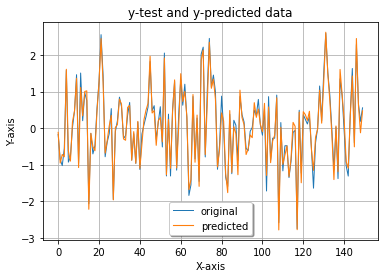

In [8]:
x_ax = range(len(ytest))
plt.plot(x_ax, ytest, linewidth=1, label="original")
plt.plot(x_ax, ypred, linewidth=1.1, label="predicted")
plt.title("y-test and y-predicted data")
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend(loc='best',fancybox=True, shadow=True)
plt.grid(True)
plt.show()

# Zadania do wykonania

<p><b>Zadanie 1</b></p>
Przeprowadź eksperymenty dla SGDRegressor dla zbioru danych zaczytanych z load_diabetes (<a>https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html#sklearn.datasets.load_diabetes</a>). Zbiór zawiera dane 442 pacjentów, z czego w pierwszych 10 jest informacja zmiennoprzecinkowa o (w kolejności) wieku, płci wskaźniku masy ciała, średnie cisnienie krwi i sześć pomiarów surowicy krwi, a w ostatniej kolumnie znajduje się ilościowa progresja choroby rok po wizycie początkowej.


![stopka.svg](stopka.svg)